### Vector Databases

A vector database in RAG is a specialized store for embeddings that allows fast similarity search, ensuring the LLM retrieves semantically relevant chunks to generate accurate answers.

example:-
```
"I love rasmalai"
↓
[0.12, -0.45, 0.89, ...]
```
- 10 vectors → easy
- 10,000 vectors → harder
- 1 million vectors → very hard

A vector database helps us quickly find:
"Which vectors are most similar to this query vector?"
```
This is called Similarity Search or Nearest Neighbor Search.


### generating 10,000 fake embeddings

In [21]:
import numpy as np
vectors=np.random.rand(10000,384).astype('float32')

In [22]:
%pip install faiss-cpu

In [23]:
## Creating index
import faiss
dimension=384
index=faiss.IndexFlatL2(dimension)
index.add(vectors)

In [24]:
query=vectors[0:1]
distances,indices=index.search(query,5)

In [25]:
import time
start = time.time()
index.search(query, 5)
end = time.time()
print(end - start)

0.01253819465637207


In [26]:
%pip install chromadb

In [27]:
import chromadb
client=chromadb.Client()
collection=client.create_collection("benchmark", get_or_create=True)

In [28]:
for i,vec in enumerate(vectors):
  collection.add(
      ids=[str(i)],
      embeddings=[vec.tolist()]

  )

In [29]:
collection.query(
    query_embeddings=[query[0].tolist()],
    n_results=5
)

{'ids': [['7466', '46448', '11593', '38817', '31857']],
 'embeddings': None,
 'documents': [[None, None, None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None, None, None, None]],
 'distances': [[51.49211120605469,
   51.506954193115234,
   51.7048225402832,
   51.758644104003906,
   51.76457977294922]]}

In [30]:
start = time.time()

collection.query(
    query_embeddings=[query[0].tolist()],
    n_results=5
)

end = time.time()
print(end-start)

0.0039784908294677734


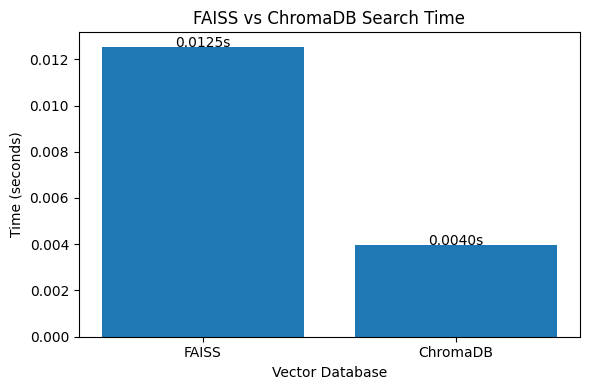

In [31]:
import matplotlib.pyplot as plt

databases = ["FAISS", "ChromaDB"]
search_times = [0.01253819465637207, 0.0039784908294677734]

plt.figure(figsize=(6,4))
plt.bar(databases, search_times)
plt.title("FAISS vs ChromaDB Search Time")
plt.ylabel("Time (seconds)")
plt.xlabel("Vector Database")

for i, v in enumerate(search_times):
    plt.text(i, v, f"{v:.4f}s", ha="center")

plt.tight_layout()
plt.show()